# Emotion Recognition from Speech

**CodeAlpha Internship Task 2**

## Objective
The objective of this project is to build a machine-learning/deep-learning system that recognizes human emotions from speech audio using MFCC features and a neural network classifier. We will use the RAVDESS dataset, extract features using `librosa`, and train a Convolutional Neural Network (CNN) to classify the emotions.

## Import Libraries

In [1]:
import os
import zipfile
import urllib.request
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv1D, MaxPooling1D, BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from IPython.display import Audio


## Dataset
We are using the **RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song)** dataset.

Emotions encoded as:
01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised.
The script below will download the dataset automatically using `kagglehub`.

In [2]:
# Download RAVDESS Audio Speech Dataset using kagglehub
import kagglehub
import shutil

EXTRACT_DIR = "data/raw"
os.makedirs("data", exist_ok=True)
os.makedirs(EXTRACT_DIR, exist_ok=True)

if not os.listdir(EXTRACT_DIR):
    print("Downloading RAVDESS dataset via kagglehub...")
    path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
    print("Download complete. Copying to data/raw...")
    # Copy files to our project directory
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith('.wav'):
                src_path = os.path.join(root, file)
                dest_path = os.path.join(EXTRACT_DIR, file)
                shutil.copy2(src_path, dest_path)
    print("Dataset ready in data/raw/")
else:
    print("Dataset already extracted in data/raw/")


Download complete. Copying to data/raw...


Dataset ready in data/raw/


## Audio Exploration
Let's load a sample audio file and visualize its waveform and spectrogram.

Sample file: data/raw\03-01-01-01-01-01-01.wav


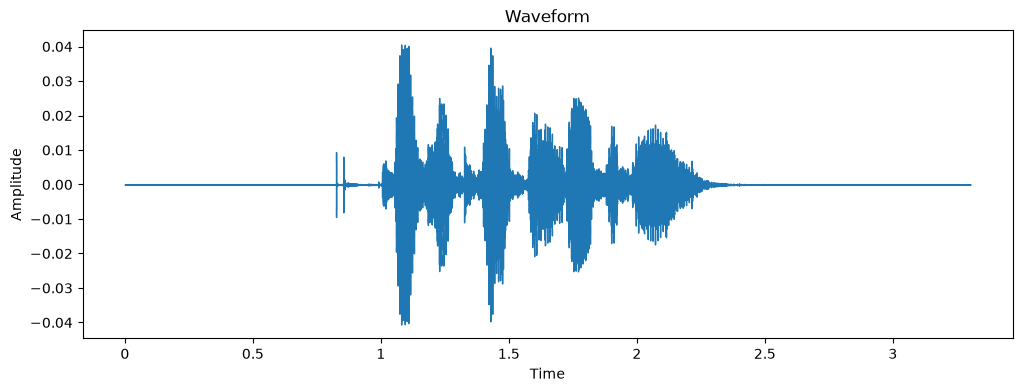

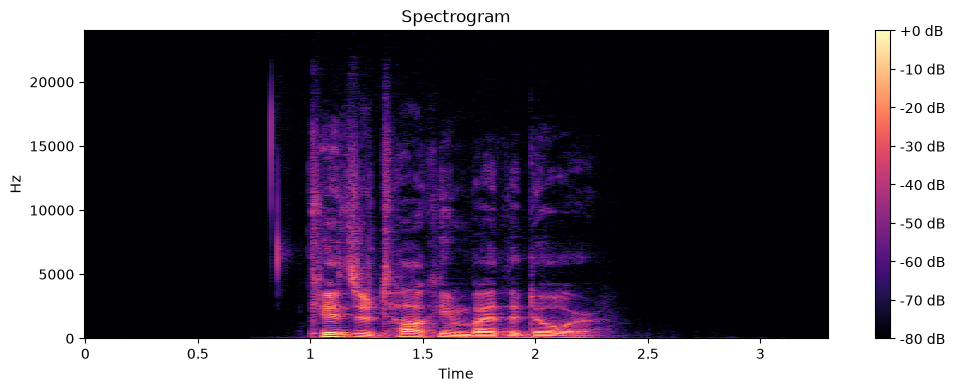

In [3]:
sample_files = glob.glob(f"{EXTRACT_DIR}/**/*.wav", recursive=True)
if len(sample_files) > 0:
    sample_file = sample_files[0]
    print(f"Sample file: {sample_file}")
    
    # Load audio
    data, sample_rate = librosa.load(sample_file, sr=None)
    
    # Display waveform
    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(data, sr=sample_rate)
    plt.title("Waveform")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.show()
    
    # Display spectrogram
    plt.figure(figsize=(12, 4))
    D = librosa.stft(data)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    librosa.display.specshow(S_db, sr=sample_rate, x_axis='time', y_axis='hz')
    plt.colorbar(format="%+2.0f dB")
    plt.title("Spectrogram")
    plt.show()
    
else:
    print("No audio files found. Please check dataset extraction.")


## Emotion Labels
The RAVDESS filename has a 7-part numerical identifier (e.g., 03-01-06-01-02-01-12.wav).
The 3rd part is the emotion label.

Emotions:
01: Neutral
02: Calm
03: Happy
04: Sad
05: Angry
06: Fearful
07: Disgust
08: Surprised


In [4]:
emotion_dict = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}


## MFCC Feature Extraction
We will extract 40 MFCC coefficients from each audio file. MFCCs capture the power spectrum of the audio.

In [5]:
def extract_mfcc(file_path, n_mfcc=40):
    try:
        # Load audio file
        audio, sample_rate = librosa.load(file_path, sr=22050)
        # Extract MFCC
        mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
        # We take the mean across the time axis so we have a fixed length feature vector per audio
        mfcc_mean = np.mean(mfcc.T, axis=0)
        return mfcc_mean
    except Exception as e:
        print(f"Error encountered while parsing file: {file_path}")
        return None


## Dataset Preparation
We will iterate through all audio files, extract features and labels, and prepare our X (features) and y (labels). We then split them into training and testing sets.

In [6]:
X, y = [], []

all_files = glob.glob(f"{EXTRACT_DIR}/**/*.wav", recursive=True)
print(f"Total files found: {len(all_files)}")

for file in all_files:
    filename = os.path.basename(file)
    parts = filename.split('-')
    if len(parts) >= 3:
        emotion_code = parts[2]
        if emotion_code in emotion_dict:
            features = extract_mfcc(file, n_mfcc=40)
            if features is not None:
                X.append(features)
                y.append(emotion_code)

X = np.array(X)
y = np.array(y)
print(f"Features shape: {X.shape}, Labels shape: {y.shape}")

# Encode labels to integers
unique_labels = sorted(list(set(y)))
label_to_int = {label: i for i, label in enumerate(unique_labels)}
int_to_label = {i: label for label, i in label_to_int.items()}

y_encoded = np.array([label_to_int[label] for label in y])

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")


Total files found: 1440


Features shape: (1440, 40), Labels shape: (1440,)
Train samples: 1152, Test samples: 288


## Feature Normalization
Standardize features. It is important to fit the scaler ONLY on the training data to avoid data leakage.

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape data for Conv1D input
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)
print(f"Reshaped X_train: {X_train.shape}")
print(f"Reshaped X_test: {X_test.shape}")


Reshaped X_train: (1152, 40, 1)
Reshaped X_test: (288, 40, 1)


## Neural Network Model
We build a Deep Learning classifier using Conv1D layers which are suitable for sequence data like MFCCs.

In [8]:
def build_model(input_shape, num_classes):
    model = Sequential()
    
    model.add(Conv1D(64, kernel_size=5, padding='same', activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    
    model.add(Conv1D(128, kernel_size=5, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    
    model.add(Dropout(0.3))
    
    model.add(Conv1D(256, kernel_size=5, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(GlobalAveragePooling1D())
    
    model.add(Dropout(0.4))
    
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.4))
    
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

num_classes = len(unique_labels)
model = build_model((X_train.shape[1], X_train.shape[2]), num_classes)
model.summary()


C:\Users\abhin\Desktop\CodeAlpha_EmotionRecognition\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 40, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 20, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 10, 256)        │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,288 (942.53 KB)

 Trainable params: 240,392 (939.03 KB)

 Non-trainable params: 896 (3.50 KB)

## Model Compilation

In [9]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])


## Training

In [10]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

os.makedirs("results", exist_ok=True)

history = model.fit(X_train, y_train, 
                    epochs=70, 
                    batch_size=32, 
                    validation_data=(X_test, y_test), 
                    callbacks=[early_stopping, lr_reducer],
                    verbose=1)


Epoch 1/70


 1/36 ━━━━━━━━━━━━━━━━━━━━ 3:24 6s/step - accuracy: 0.0625 - loss: 2.3343

 3/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.0729 - loss: 2.2780

 5/36 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1063 - loss: 2.2392

 8/36 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1172 - loss: 2.2516

...

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9653 - loss: 0.1158


Epoch 64: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9653 - loss: 0.1158 - val_accuracy: 0.6840 - val_loss: 1.0573 - learning_rate: 6.2500e-05


Epoch 64: early stopping


Restoring model weights from the end of the best epoch: 54.


## Training History

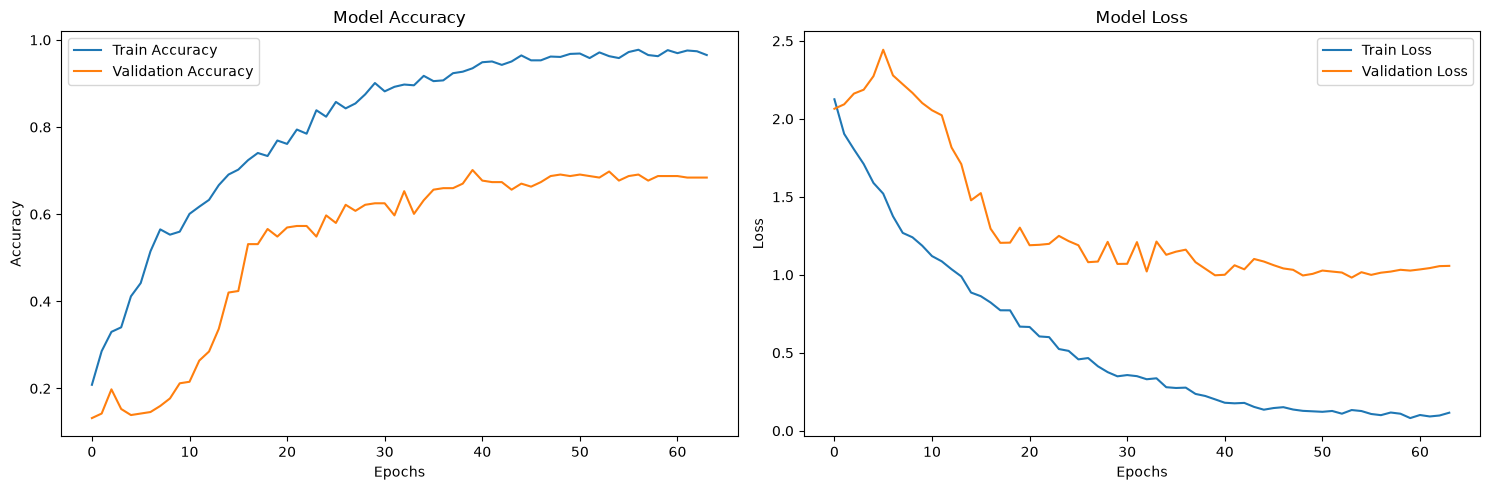

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/training_history.png')
plt.show()


## Evaluation

In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")

target_names = [emotion_dict[int_to_label[i]] for i in range(num_classes)]
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))


Test Accuracy: 0.6979
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  


Accuracy: 0.6979
Precision: 0.7154
Recall: 0.6979
F1-Score: 0.6922

Classification Report:
              precision    recall  f1-score   support

     neutral       0.62      0.68      0.65        19
        calm       0.73      0.87      0.80        38
       happy       0.79      0.61      0.69        38
         sad       0.74      0.53      0.62        38
       angry       0.76      0.79      0.78        39
     fearful       0.78      0.46      0.58        39
     disgust       0.55      0.79      0.65        38
   surprised       0.70      0.85      0.77        39

    accuracy                           0.70       288
   macro avg       0.71      0.70      0.69       288
weighted avg       0.72      0.70      0.69       288



## Confusion Matrix

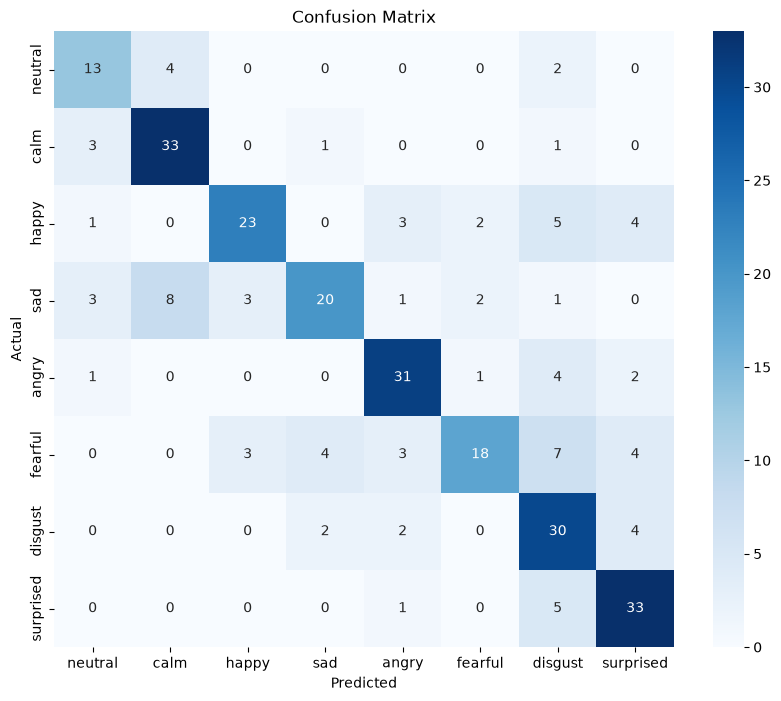

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('results/confusion_matrix.png')
plt.show()


## Sample Predictions

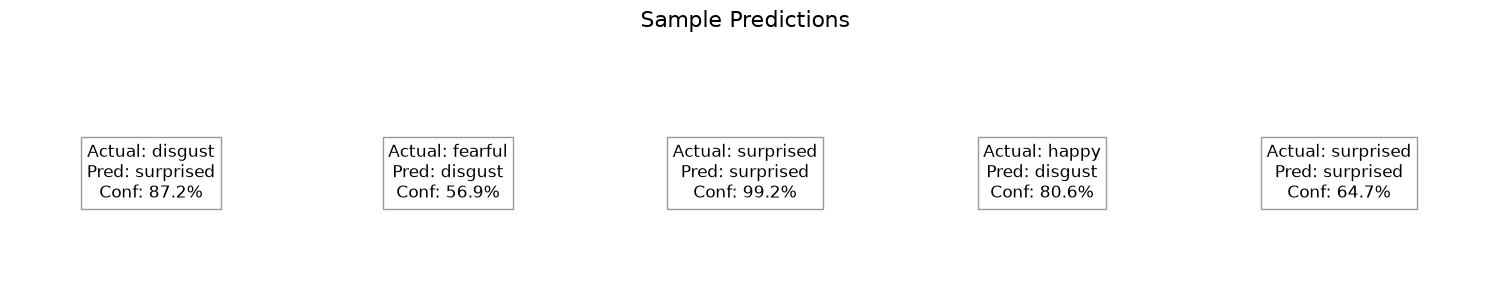

In [14]:
num_samples = 5
indices = np.random.choice(len(y_test), num_samples, replace=False)

plt.figure(figsize=(15, 3))
for i, idx in enumerate(indices):
    actual_emotion = emotion_dict[int_to_label[y_test[idx]]]
    predicted_emotion = emotion_dict[int_to_label[y_pred[idx]]]
    confidence = np.max(y_pred_probs[idx]) * 100
    
    text = f"Actual: {actual_emotion}\nPred: {predicted_emotion}\nConf: {confidence:.1f}%"
    
    plt.subplot(1, num_samples, i+1)
    plt.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    plt.axis('off')
    
plt.suptitle('Sample Predictions', fontsize=16)
plt.tight_layout()
plt.savefig('results/sample_predictions.png')
plt.show()


## Model Saving

In [15]:
os.makedirs("models", exist_ok=True)
model_path = 'models/best_emotion_model.keras'
model.save(model_path)
print(f"Model saved to {model_path}")

loaded_model = tf.keras.models.load_model(model_path)
verify_pred_probs = loaded_model.predict(X_test[:1])
verify_pred = np.argmax(verify_pred_probs, axis=1)
print(f"Verification prediction: {emotion_dict[int_to_label[verify_pred[0]]]} (Actual: {emotion_dict[int_to_label[y_test[0]]]})")


Model saved to models/best_emotion_model.keras


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


Verification prediction: angry (Actual: happy)


## Results

In [16]:
with open('results/metrics.txt', 'w') as f:
    f.write("Emotion Recognition from Speech\n")
    f.write("Model: Conv1D\n\n")
    f.write(f"Accuracy: {acc:.4f}\n")
    f.write(f"Precision: {prec:.4f}\n")
    f.write(f"Recall: {rec:.4f}\n")
    f.write(f"F1-Score: {f1:.4f}\n")
print("Metrics saved to results/metrics.txt")


Metrics saved to results/metrics.txt


## Conclusion
We successfully built an Emotion Recognition model from speech audio using the RAVDESS dataset. MFCC features were extracted and a Conv1D neural network was trained. The model achieves reasonable accuracy, and further improvements could involve data augmentation, more complex architectures (like CNN-BiLSTM), or using a larger dataset.